<h1><strong>Outliers</strong></h1>

An outlier is a data point that is abnormally distant from all other observations in you dataset. It is an anomaly that does not fit in pattern.

<h2><strong>Types of outliers</strong></h2>

- <code>Global Outliers:</code> A point far outside the range of entire dataset (age : 150)
- <code>Contextual outliers:</code> A point that is an anomaly in a specific context, but normal otherwise (eg. 30C is normal in summer, but abnormal in winter)
- <code>Collective outliers:</code> A subset of data points that deviate together as group (eg. a sudden string of 0 sales for 5 days due to website crash.)

In [2]:
import numpy as np
import pandas as pd

In [5]:
ages = np.random.normal(loc=25,scale=5,size=200)

outliers = np.array([120,150,-10])
data_ = np.concatenate([ages,outliers])

df = pd.DataFrame({"Age":data_})

In [9]:
df['Age']

0       30.654542
1       22.668691
2       25.078012
3       15.454022
4       29.614917
          ...    
198     17.834700
199     23.743924
200    120.000000
201    150.000000
202    -10.000000
Name: Age, Length: 203, dtype: float64

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

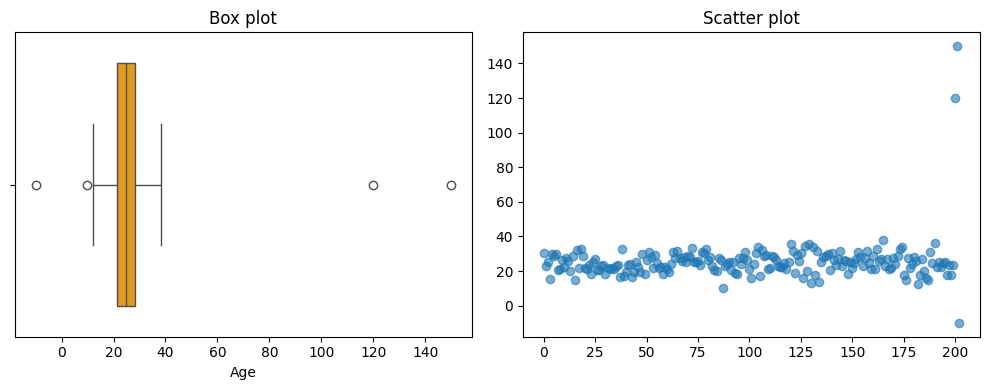

In [10]:
plt.figure(figsize=(10,4))

#box plot
plt.subplot(1,2,1)
sns.boxplot(x=df['Age'],color='orange')
plt.title("Box plot")

plt.subplot(1,2,2)
plt.scatter(range(len(df)),df['Age'],alpha=0.6)
plt.title("Scatter plot")

plt.tight_layout()
plt.show()

<h2><strong>Detect outliers (IQR(Inter quartile range) Method)</storng></h2>

In [12]:
#calculate = Q1 (25 percentile) and Q3 (75 percentile)
#IQR = Q3 - Q1
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)

IQR = Q3 - Q1

print(IQR)

7.023866279320558


In [13]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound,upper_bound)

10.778226826811014 38.873691944093245


In [14]:
df['Age_capping'] = np.where(df['Age']>upper_bound, upper_bound,np.where(df['Age']<lower_bound,lower_bound,df['Age']))

In [15]:
df

,Age,Age_capping
0,30.654542,30.654542
1,22.668691,22.668691
2,25.078012,25.078012
3,15.454022,15.454022
4,29.614917,29.614917
...,...,...
198,17.834700,17.834700
199,23.743924,23.743924
200,120.000000,38.873692
201,150.000000,38.873692


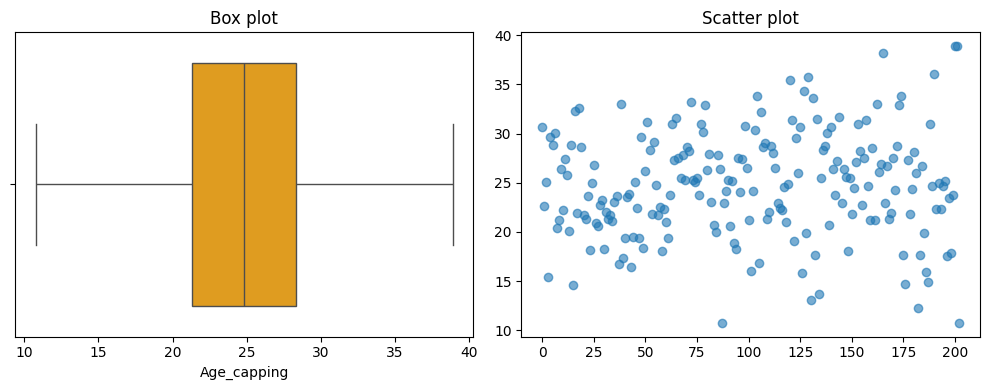

In [16]:
plt.figure(figsize=(10,4))

#box plot
plt.subplot(1,2,1)
sns.boxplot(x=df['Age_capping'],color='orange')
plt.title("Box plot")

plt.subplot(1,2,2)
plt.scatter(range(len(df)),df['Age_capping'],alpha=0.6)
plt.title("Scatter plot")

plt.tight_layout()
plt.show()

<h2><strong>Z-Score</strong></h2>


Use the z-score with symmetric data

In [21]:
from scipy.stats import zscore

In [17]:
np.random.seed(42)

x = np.random.normal(loc=120,scale=10,size=200)

outliers = np.array([190,50,250])
data = np.concatenate([x,outliers])

df = pd.DataFrame({"X":data})

In [18]:
df

,X
0,124.967142
1,118.617357
2,126.476885
3,135.230299
4,117.658466
...,...
198,120.582087
199,108.570297
200,190.000000
201,50.000000


In [22]:
df['Z_score'] = zscore(df['X'])

In [23]:
df

,X,Z_score
0,124.967142,0.321281
1,118.617357,-0.110165
2,126.476885,0.423863
3,135.230299,1.018628
4,117.658466,-0.175319
...,...,...
198,120.582087,0.023331
199,108.570297,-0.792829
200,190.000000,4.740045
201,50.000000,-4.772484


Thresh value should be 3 or -3

In [24]:
thres = 3

outliers_detected = df[(df['Z_score']>thres) | (df['Z_score']< -thres)]

In [25]:
outliers_detected

,X,Z_score
200,190.0,4.740045
201,50.0,-4.772484
202,250.0,8.816843
